11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.2434 - val_loss: 0.1759
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1627 - val_loss: 0.1497
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1455 - val_loss: 0.1397
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1381 - val_loss: 0.1342
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1324 - val_loss: 0.1291
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


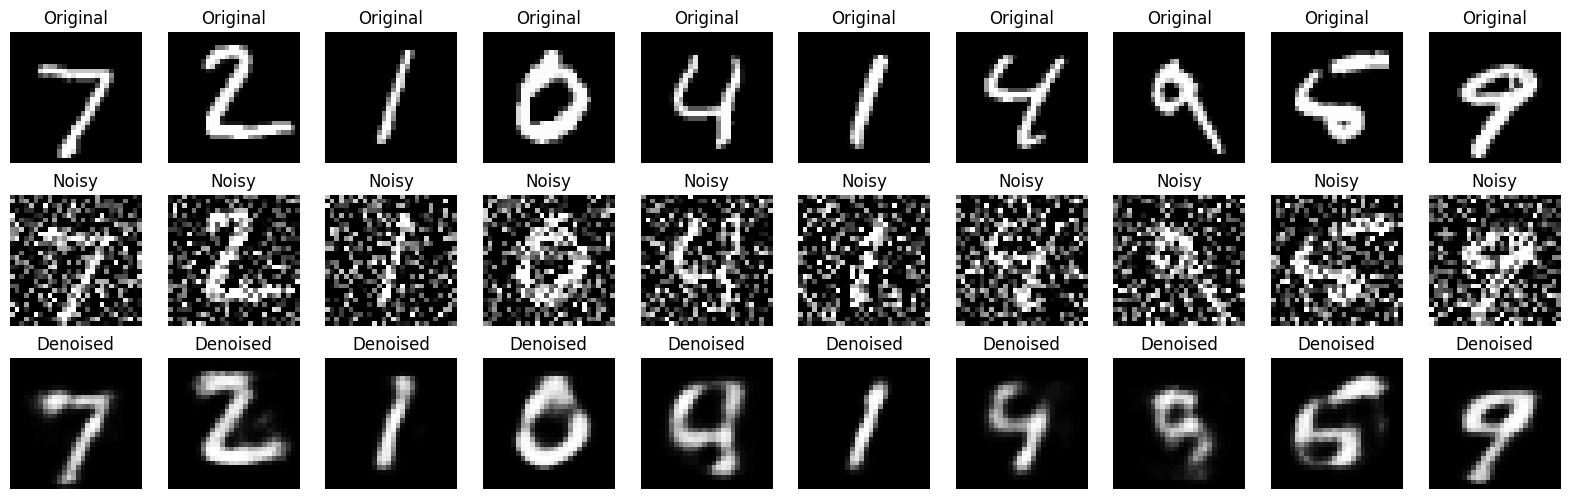

Autoencoder Denoising Completed ✅


In [1]:
# ================================
# AUTOENCODER FOR IMAGE DENOISING
# ================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

# -------------------------------
# 1. Load Dataset
# -------------------------------
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# -------------------------------
# 2. Add Noise
# -------------------------------
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# -------------------------------
# 3. Build Autoencoder
# -------------------------------
input_img = Input(shape=(28, 28))

x = Flatten()(input_img)
x = Dense(128, activation='relu')(x)
encoded = Dense(64, activation='relu')(x)

x = Dense(128, activation='relu')(encoded)
x = Dense(784, activation='sigmoid')(x)
decoded = Reshape((28, 28))(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

# -------------------------------
# 4. Train Model
# -------------------------------
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# -------------------------------
# 5. Denoise Images
# -------------------------------
decoded_imgs = autoencoder.predict(x_test_noisy)

# -------------------------------
# 6. Visualization
# -------------------------------
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

print("Autoencoder Denoising Completed ✅")

In [2]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1283 - val_loss: 0.1258
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1258 - val_loss: 0.1244
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1240 - val_loss: 0.1224
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.1224 - val_loss: 0.1211
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1210 - val_loss: 0.1201


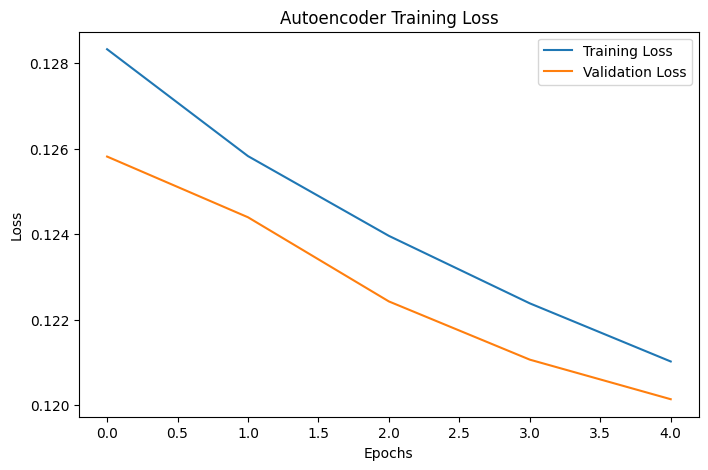

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

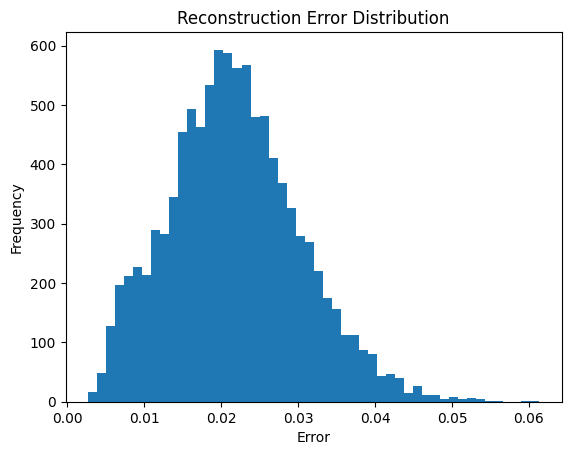

In [4]:
import numpy as np

reconstruction_error = np.mean((x_test - decoded_imgs)**2, axis=(1,2))

plt.hist(reconstruction_error, bins=50)
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()